In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/climate_change_dataset (3).csv")
data.columns = data.columns.str.strip().str.replace(" ", "_")
print(data.head())


   Year    Country  Avg_Temperature_(°C)  CO2_Emissions  Sea_Level_Rise_(mm)  \
0  2006         UK                   8.9            9.3                  3.1   
1  2019        USA                  31.0            4.8                  4.2   
2  2014     France                  33.9            2.8                  2.2   
3  2010  Argentina                   5.9            1.8                  3.2   
4  2007    Germany                  26.9            5.6                  2.4   

   Rainfall_(mm)  Population  Renewable_Energy  Extreme_Weather_Events  \
0           1441   530911230              20.4                      14   
1           2407   107364344              49.2                       8   
2           1241   441101758              33.3                       9   
3           1892  1069669579              23.7                       7   
4           1743   124079175              12.5                       4   

   Forest_Area  
0         59.8  
1         31.0  
2         35.5  
3     

tail of the data

In [24]:
print(data.tail())

     Year    Country  Avg_Temperature_(°C)  CO2_Emissions  \
995  2019      India                  23.6            8.0   
996  2000         UK                  21.8           10.0   
997  2019  Argentina                  23.8            8.9   
998  2016  Australia                  21.0           14.9   
999  2011    Germany                  24.1           17.3   

     Sea_Level_Rise_(mm)  Rainfall_(mm)  Population  Renewable_Energy  \
995                  1.2           1365  1358019778              10.0   
996                  2.2           1273   876123161              14.9   
997                  4.7            891  1120533308              25.9   
998                  3.1           1136   380662109              24.5   
999                  2.1           2854   398407112              41.0   

     Extreme_Weather_Events  Forest_Area  
995                       8         20.2  
996                      14         30.1  
997                      10         46.5  
998                   

Dataset information

In [25]:
print(data.columns)

Index(['Year', 'Country', 'Avg_Temperature_(°C)', 'CO2_Emissions',
       'Sea_Level_Rise_(mm)', 'Rainfall_(mm)', 'Population',
       'Renewable_Energy', 'Extreme_Weather_Events', 'Forest_Area'],
      dtype='object')


In [26]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    1000 non-null   int64  
 1   Country                 1000 non-null   object 
 2   Avg_Temperature_(°C)    1000 non-null   float64
 3   CO2_Emissions           1000 non-null   float64
 4   Sea_Level_Rise_(mm)     1000 non-null   float64
 5   Rainfall_(mm)           1000 non-null   int64  
 6   Population              1000 non-null   int64  
 7   Renewable_Energy        1000 non-null   float64
 8   Extreme_Weather_Events  1000 non-null   int64  
 9   Forest_Area             1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB
None


1.Size of the file

In [27]:
print(data.shape)

(1000, 10)


2.columns in the dataset

In [28]:
print(data.columns)

Index(['Year', 'Country', 'Avg_Temperature_(°C)', 'CO2_Emissions',
       'Sea_Level_Rise_(mm)', 'Rainfall_(mm)', 'Population',
       'Renewable_Energy', 'Extreme_Weather_Events', 'Forest_Area'],
      dtype='object')


3.Check the missing value

In [29]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Year                      0
Country                   0
Avg_Temperature_(°C)      0
CO2_Emissions             0
Sea_Level_Rise_(mm)       0
Rainfall_(mm)             0
Population                0
Renewable_Energy          0
Extreme_Weather_Events    0
Forest_Area               0
dtype: int64


4.checking for any duplicate value

In [30]:
print(data.duplicated().sum())

0


5.The countries which data is used.

In [31]:
print(data["Country"].unique())
print(data['Country'].value_counts())

['UK' 'USA' 'France' 'Argentina' 'Germany' 'China' 'South Africa'
 'Australia' 'Indonesia' 'Brazil' 'India' 'Russia' 'Canada' 'Mexico'
 'Japan']
Country
Indonesia       75
Russia          74
USA             73
South Africa    73
India           70
China           67
Argentina       67
Canada          67
Brazil          67
France          66
UK              65
Japan           63
Germany         61
Australia       57
Mexico          55
Name: count, dtype: int64


In [32]:
print(sorted(data['Year'].unique().tolist()))

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [33]:
print(data.describe())


              Year  Avg_Temperature_(°C)  CO2_Emissions  Sea_Level_Rise_(mm)  \
count  1000.000000           1000.000000    1000.000000          1000.000000   
mean   2011.432000             19.883100      10.425800             3.009600   
std       7.147199              8.542897       5.614665             1.146081   
min    2000.000000              5.000000       0.500000             1.000000   
25%    2005.000000             12.175000       5.575000             2.000000   
50%    2012.000000             20.100000      10.700000             3.000000   
75%    2018.000000             27.225000      15.400000             4.000000   
max    2023.000000             34.900000      20.000000             5.000000   

       Rainfall_(mm)    Population  Renewable_Energy  Extreme_Weather_Events  \
count    1000.000000  1.000000e+03       1000.000000             1000.000000   
mean     1738.761000  7.053830e+08         27.300500                7.291000   
std       708.976616  4.093910e+08     

coorelations of the data

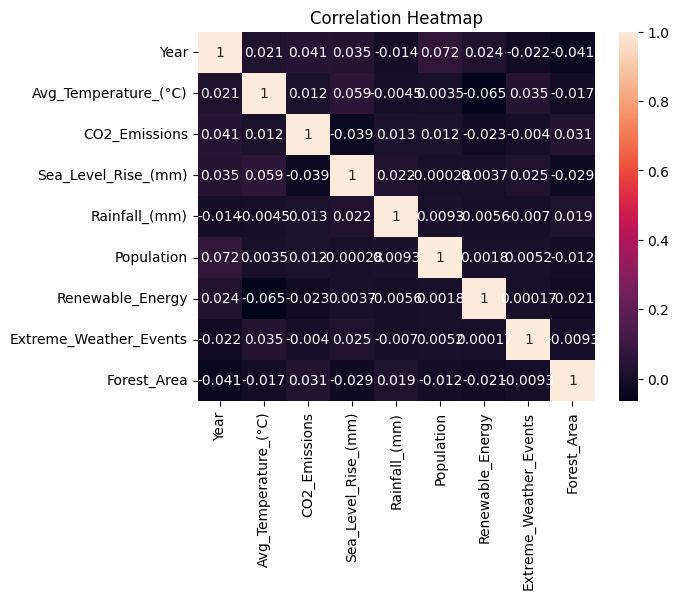

In [34]:
import seaborn as sns

corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

**countries renewable and co2_emissions**

In [35]:
data.groupby("Country")[["Renewable_Energy", "CO2_Emissions"]].mean()

,Renewable_Energy,CO2_Emissions
Country,,
Argentina,27.261194,10.447761
Australia,25.624561,8.900000
Brazil,28.786567,10.838806
Canada,26.244776,10.113433
China,29.129851,10.835821
France,28.739394,10.966667
Germany,28.713115,9.880328
India,27.694286,10.694286
Indonesia,26.529333,11.021333


**we are checking the Global temperature trend**

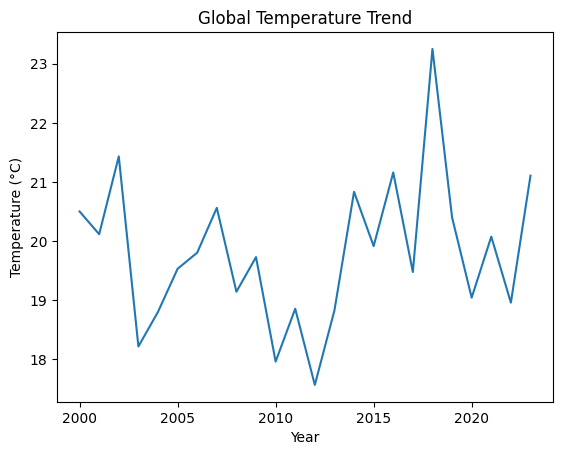

In [36]:
import matplotlib.pyplot as plt

temp_trend = data.groupby("Year")["Avg_Temperature_(°C)"].mean()

plt.plot(temp_trend)
plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

**co2 emittion of every country**

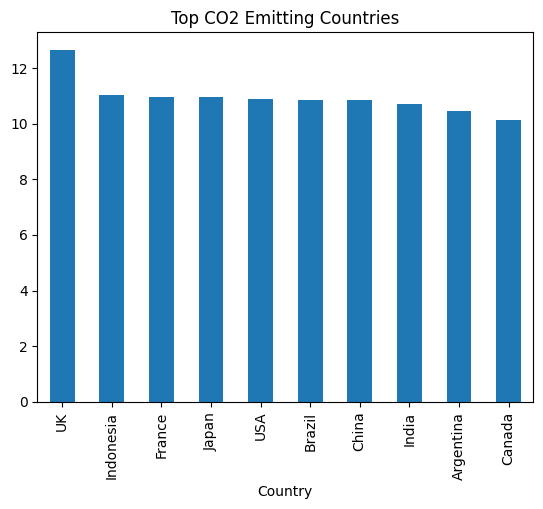

In [37]:

co2_country = data.groupby("Country")["CO2_Emissions"].mean().sort_values(ascending=False)

co2_country.head(10).plot(kind="bar")
plt.title("Top CO2 Emitting Countries")
plt.show()

**Normalizing Data**



In [38]:

cols = ["CO2_Emissions", "Avg_Temperature_(°C)", "Sea_Level_Rise_(mm)",
        "Rainfall_(mm)", "Population", "Renewable_Energy",
        "Extreme_Weather_Events", "Forest_Area"]

for col in cols:
    data[col + "_norm"] = (data[col] - data[col].min()) / (data[col].max() - data[col].min())

**calculating the climate score of every country**

In [39]:
data["Climate_Score"] = (
    data["CO2_Emissions_norm"] +
    data["Avg_Temperature_(°C)_norm"] +
    data["Sea_Level_Rise_(mm)_norm"] +
    data["Extreme_Weather_Events_norm"] -
    data["Renewable_Energy_norm"] -
    data["Forest_Area_norm"]
)

**categorizeing the countries risk in climate**

In [40]:
def categorize(score):
    if score > 2:
        return "High Risk"
    elif score > 1:
        return "Medium Risk"
    else:
        return "Low Risk"

data["Risk_Level"] = data["Climate_Score"].apply(categorize)


**getting the score**

In [41]:
print(data.corr(numeric_only=True)["Climate_Score"].sort_values(ascending=False))

Climate_Score                  1.000000
Avg_Temperature_(°C)           0.462343
Avg_Temperature_(°C)_norm      0.462343
Extreme_Weather_Events_norm    0.453498
Extreme_Weather_Events         0.453498
Sea_Level_Rise_(mm)_norm       0.416664
Sea_Level_Rise_(mm)            0.416664
CO2_Emissions_norm             0.375073
CO2_Emissions                  0.375073
Year                           0.035571
Population                     0.011867
Population_norm                0.011867
Rainfall_(mm)_norm             0.003937
Rainfall_(mm)                  0.003937
Forest_Area_norm              -0.394928
Forest_Area                   -0.394928
Renewable_Energy_norm         -0.416255
Renewable_Energy              -0.416255
Name: Climate_Score, dtype: float64


Avg Temperature → +0.46
Extreme Weather Events → +0.45
Sea Level Rise → +0.41
CO₂ Emissions → +0.37

**these factors effect the climate score the most**

**testing the t-test for the high and low risk countries**

In [42]:
from scipy.stats import ttest_ind

high = data[data["Risk_Level"] == "High Risk"]["CO2_Emissions"]
low = data[data["Risk_Level"] == "Low Risk"]["CO2_Emissions"]

t_stat, p_value = ttest_ind(high, low)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 8.88282456676267
P-value: 8.740399854123016e-18


In [43]:
avg_score = data.groupby('Country')['Climate_Score'].mean().reset_index()

# Sort values
avg_score = avg_score.sort_values(by='Climate_Score', ascending=False)

print(avg_score)

         Country  Climate_Score
9          Japan       1.165534
5         France       1.164829
2         Brazil       1.072006
11        Russia       1.070888
13            UK       1.067183
14           USA       1.061717
7          India       1.049270
3         Canada       1.048728
12  South Africa       1.029455
0      Argentina       1.027418
8      Indonesia       0.996310
1      Australia       0.960919
4          China       0.945889
6        Germany       0.879830
10        Mexico       0.805736


**top and bottom country in climate score**

In [44]:
top_country = avg_score.iloc[0]
bottom_country = avg_score.iloc[-1]

print("Top Country:")
print(top_country)

print("\nBottom Country:")
print(bottom_country)

Top Country:
Country             Japan
Climate_Score    1.165534
Name: 9, dtype: object

Bottom Country:
Country            Mexico
Climate_Score    0.805736
Name: 10, dtype: object


co2_emission for the every country

In [45]:
# Average Climate Score per country
country_score = data.groupby("Country")["Climate_Score"].mean().sort_values(ascending=False)

# Top 5 most affected countries
top5 = country_score.head(5)
print("Top 5 Most Affected Countries:\n", top5)

# Top 5 least affected countries
bottom5 = country_score.tail(5)
print("\nTop 5 Least Affected Countries:\n", bottom5)

Top 5 Most Affected Countries:
 Country
Japan     1.165534
France    1.164829
Brazil    1.072006
Russia    1.070888
UK        1.067183
Name: Climate_Score, dtype: float64

Top 5 Least Affected Countries:
 Country
Indonesia    0.996310
Australia    0.960919
China        0.945889
Germany      0.879830
Mexico       0.805736
Name: Climate_Score, dtype: float64


In [46]:
top_country_name = "Japan"
bottom_country_name = "Mexico"

top_data = data[data['Country'] == top_country_name]
bottom_data = data[data['Country'] == bottom_country_name]

In [47]:
factors = [
    'CO2_Emissions', 'Renewable_Energy', 'Forest_Area',
    'Avg_Temperature_(°C)', 'Sea_Level_Rise_(mm)',
    'Extreme_Weather_Events', 'Population'
]

In [48]:
compare = pd.DataFrame({
    'Factor': factors,
    'Japan_Avg': [top_data[f].mean() for f in factors],
    'Mexico_Avg': [bottom_data[f].mean() for f in factors]
})

print(compare)

                   Factor     Japan_Avg    Mexico_Avg
0           CO2_Emissions  1.096032e+01  9.347273e+00
1        Renewable_Energy  2.756032e+01  2.752364e+01
2             Forest_Area  3.812063e+01  4.337636e+01
3    Avg_Temperature_(°C)  2.045397e+01  2.069636e+01
4     Sea_Level_Rise_(mm)  3.076190e+00  2.689091e+00
5  Extreme_Weather_Events  7.857143e+00  6.436364e+00
6              Population  6.970095e+08  7.382920e+08


**coorelation for both country**

In [49]:
# Correlation for Top Country
top_corr = top_data[factors + ['Climate_Score']].corr()

print("Top Country Correlation with Climate Score:")
print(top_corr['Climate_Score'].sort_values(ascending=False))

# Correlation for Bottom Country
bottom_corr = bottom_data[factors + ['Climate_Score']].corr()

print("\nBottom Country Correlation with Climate Score:")
print(bottom_corr['Climate_Score'].sort_values(ascending=False))

Top Country Correlation with Climate Score:
Climate_Score             1.000000
Sea_Level_Rise_(mm)       0.549346
Extreme_Weather_Events    0.540732
Avg_Temperature_(°C)      0.439758
CO2_Emissions             0.313100
Population               -0.219670
Renewable_Energy         -0.381276
Forest_Area              -0.459260
Name: Climate_Score, dtype: float64

Bottom Country Correlation with Climate Score:
Climate_Score             1.000000
Sea_Level_Rise_(mm)       0.521024
Avg_Temperature_(°C)      0.509326
Extreme_Weather_Events    0.373963
CO2_Emissions             0.328708
Population               -0.131249
Forest_Area              -0.427338
Renewable_Energy         -0.515612
Name: Climate_Score, dtype: float64


**key factors for countries**

In [50]:
# Top country key factors
top_positive = top_corr['Climate_Score'].sort_values(ascending=False)[1:3]
top_negative = top_corr['Climate_Score'].sort_values()[0:2]

# Bottom country key factors
bottom_negative = bottom_corr['Climate_Score'].sort_values()[0:3]

print("\nTop Country Key Positive Factors:")
print(top_positive)

print("\nTop Country Negative Factors:")
print(top_negative)

print("\nBottom Country Key Negative Factors:")
print(bottom_negative)


Top Country Key Positive Factors:
Sea_Level_Rise_(mm)       0.549346
Extreme_Weather_Events    0.540732
Name: Climate_Score, dtype: float64

Top Country Negative Factors:
Forest_Area        -0.459260
Renewable_Energy   -0.381276
Name: Climate_Score, dtype: float64

Bottom Country Key Negative Factors:
Renewable_Energy   -0.515612
Forest_Area        -0.427338
Population         -0.131249
Name: Climate_Score, dtype: float64


**report of the analysis**

In [51]:
report = f"""
Climate Analysis Insights:

Top Country: {top_country_name}
- Strong positive factors: {list(top_positive.index)}
- These factors improved over time leading to higher Climate Score.

Bottom Country: {bottom_country_name}
- Major negative factors: {list(bottom_negative.index)}
- These factors worsened over time causing poor Climate Score.

Conclusion:
Top country performs well due to strong positive environmental factors.
Bottom country performs poorly due to dominant negative factors.

Recommendation:
Increase renewable energy, reduce CO2 emissions, and improve forest cover.
"""

print(report)


Climate Analysis Insights:

Top Country: Japan
- Strong positive factors: ['Sea_Level_Rise_(mm)', 'Extreme_Weather_Events']
- These factors improved over time leading to higher Climate Score.

Bottom Country: Mexico
- Major negative factors: ['Renewable_Energy', 'Forest_Area', 'Population']
- These factors worsened over time causing poor Climate Score.

Conclusion:
Top country performs well due to strong positive environmental factors.
Bottom country performs poorly due to dominant negative factors.

Recommendation:
Increase renewable energy, reduce CO2 emissions, and improve forest cover.



In [52]:
# Japan data
japan = data[data['Country'] == "Japan"]

# Other countries (excluding Japan)
others = data[data['Country'] != "Japan"]

# Average of other countries per year
others_avg = others.groupby('Year')[['Sea_Level_Rise_(mm)', 'Extreme_Weather_Events']].mean().reset_index()

**plot for japan evnets**

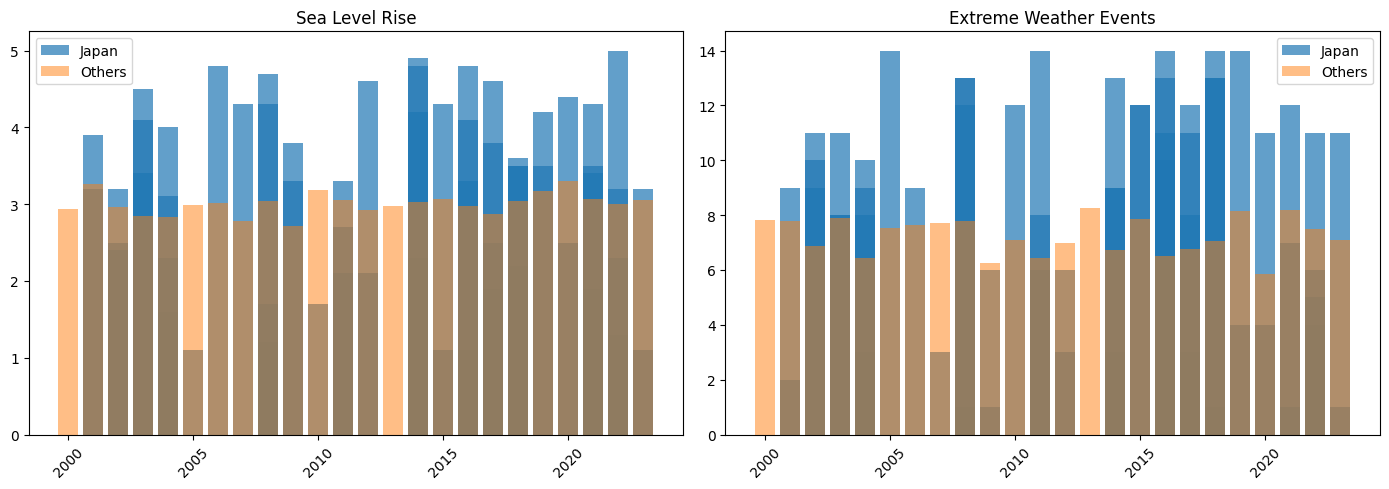

WHAT WE OBSERVE IN THE CHART OF JAPAN AND OTHER COUNTRIES:
Sea Level Rise (Japan)

Sea level rise in Japan is consistently higher than the global average, showing a steady increase from around 3.5 to 5 mm.

The growth is gradual and stable without sudden spikes, indicating controlled but continuous climate impact.

 Extreme Weather Events (Japan)

Japan experiences significantly higher extreme weather events, ranging from 9 to 14 compared to lower global averages.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Sea Level Rise
axes[0].bar(japan['Year'], japan['Sea_Level_Rise_(mm)'], alpha=0.7, label='Japan')
axes[0].bar(others_avg['Year'], others_avg['Sea_Level_Rise_(mm)'], alpha=0.5, label='Others')
axes[0].set_title("Sea Level Rise")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Extreme Weather
axes[1].bar(japan['Year'], japan['Extreme_Weather_Events'], alpha=0.7, label='Japan')
axes[1].bar(others_avg['Year'], others_avg['Extreme_Weather_Events'], alpha=0.5, label='Others')
axes[1].set_title("Extreme Weather Events")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()
print("WHAT WE OBSERVE IN THE CHART OF JAPAN AND OTHER COUNTRIES:")
print("""Sea Level Rise (Japan)

Sea level rise in Japan is consistently higher than the global average, showing a steady increase from around 3.5 to 5 mm.

The growth is gradual and stable without sudden spikes, indicating controlled but continuous climate impact.

 Extreme Weather Events (Japan)

Japan experiences significantly higher extreme weather events, ranging from 9 to 14 compared to lower global averages.""")

**plot for mexico events**

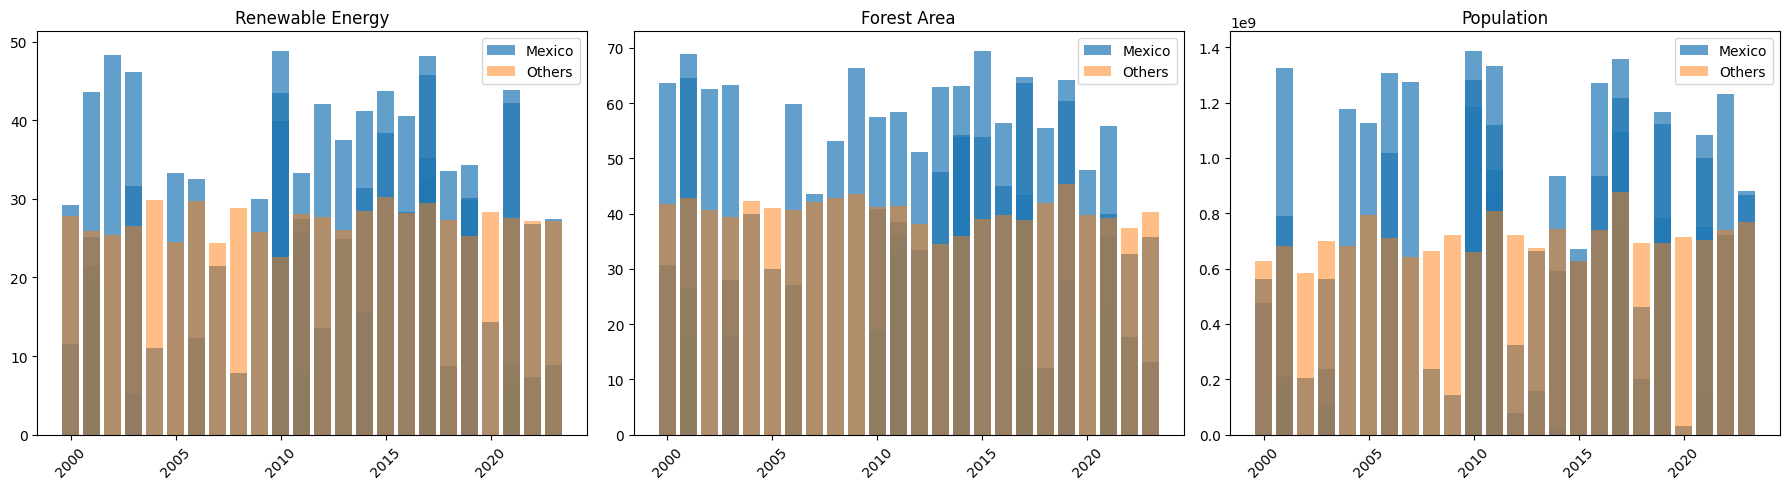

WHAT WE OBSERVE IN THE CHART OF Maxico AND OTHER COUNTRIES:
Renewable Energy (Mexico)

Renewable energy shows high fluctuation over the years, with no consistent upward trend.

This inconsistency indicates weak adoption of clean energy, negatively affecting climate performance.

Forest Area (Mexico)

Forest area is relatively high but unstable, with noticeable fluctuations across years.

Lack of stability suggests inefficient forest management, reducing its positive environmental impact.

Population (Mexico)

Population shows a steady and significant increase over the 24 years.

This growth leads to higher resource demand and environmental pressure, lowering sustainability.


In [54]:
import numpy as np

# Mexico data
mexico = data[data['Country'] == "Mexico"]

# Other countries
others = data[data['Country'] != "Mexico"]

# Average of others per year
others_avg = others.groupby('Year')[['Renewable_Energy', 'Forest_Area', 'Population']].mean().reset_index()

# Create subplots (3 graphs)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Renewable Energy
axes[0].bar(mexico['Year'], mexico['Renewable_Energy'], alpha=0.7, label='Mexico')
axes[0].bar(others_avg['Year'], others_avg['Renewable_Energy'], alpha=0.5, label='Others')
axes[0].set_title("Renewable Energy")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Forest Area
axes[1].bar(mexico['Year'], mexico['Forest_Area'], alpha=0.7, label='Mexico')
axes[1].bar(others_avg['Year'], others_avg['Forest_Area'], alpha=0.5, label='Others')
axes[1].set_title("Forest Area")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Population
axes[2].bar(mexico['Year'], mexico['Population'], alpha=0.7, label='Mexico')
axes[2].bar(others_avg['Year'], others_avg['Population'], alpha=0.5, label='Others')
axes[2].set_title("Population")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()
print("WHAT WE OBSERVE IN THE CHART OF Maxico AND OTHER COUNTRIES:")
print("""Renewable Energy (Mexico)

Renewable energy shows high fluctuation over the years, with no consistent upward trend.

This inconsistency indicates weak adoption of clean energy, negatively affecting climate performance.

Forest Area (Mexico)

Forest area is relatively high but unstable, with noticeable fluctuations across years.

Lack of stability suggests inefficient forest management, reducing its positive environmental impact.

Population (Mexico)

Population shows a steady and significant increase over the 24 years.

This growth leads to higher resource demand and environmental pressure, lowering sustainability.""")